# Estimer le renouvellement d'air à partir du CO2

Les notebooks précédents ont montré que le CO2 renseigne sur la **présence**,
mais mal sur le **nombre** d'occupants (AUC 0.65). L'explication avancée était
physique : la concentration observée résulte d'un équilibre entre ce que les
occupants produisent et ce que la ventilation évacue. Deux personnes dans un
logement bien ventilé peuvent produire la même concentration qu'une seule dans
un logement confiné.

Ce notebook cherche à mesurer le second terme — le **taux de renouvellement
d'air** — pour l'isoler du premier.

**Principe.** En l'absence d'occupants, plus aucun CO2 n'est produit : la
concentration décroît vers celle de l'air extérieur, d'autant plus vite que le
renouvellement est élevé. Cette décroissance suit

$$C(t) = C_{ext} + (C_0 - C_{ext})\,e^{-nt}$$

où **n** est le taux de renouvellement d'air, exprimé en volumes par heure
(h⁻¹). Un logement à n = 0.5 renouvelle la moitié de son air chaque heure.

Le semainier permet d'identifier avec certitude les périodes d'inoccupation,
condition indispensable pour que cette décroissance traduise bien la seule
ventilation.

**Démarche :**
1. Identifier les plages d'absence exploitables
2. Estimer n par ajustement de la décroissance
3. Vérifier la plausibilité physique des valeurs obtenues
4. Confronter au type de ventilation déclaré
5. Le renouvellement d'air permet-il de mieux estimer le nombre d'occupants ?


## 1. Données et repérage des périodes d'inoccupation


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)

DATA = '../data/cln1/Raw'
IDN_EXTERIEUR = 90

C_EXT = 400.0


In [2]:
# ── CO2, journées complètes
co2 = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                  encoding='latin1', usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR'],
                  parse_dates=['DATE_HEURE'])
co2['VALEUR'] = pd.to_numeric(co2['VALEUR'], errors='coerce')
co2 = co2.dropna(subset=['VALEUR']).sort_values(['CODELIEU', 'DATE_HEURE'])
co2['DATE'] = co2['DATE_HEURE'].dt.normalize()
n_pts = co2.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('size')
co2 = co2[n_pts == 144].copy()
co2['tranche'] = co2.groupby(['CODELIEU', 'DATE']).cumcount()

# ── Semainier : absence de TOUS les occupants du logement
# On exige ici l'absence du logement entier, et non de la seule pièce du capteur :
# une personne restée au salon continue de produire du CO2 qui diffuse vers les
# autres pièces, ce qui fausserait la décroissance observée.
sem = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_SEMAINIER_DATA.txt',
                  sep='\t', encoding='latin1')
sem['DATE'] = pd.to_datetime(sem['DATE'], format='%d/%m/%Y')
sem = sem[sem['CODE_HEURE'].str.startswith('V_1')].copy()
sem['tranche'] = sem['CODE_HEURE'].str[2:].astype(int) - 1001
renseigne = sem['IDN_PIECE'].notna()
sem['dans_logement'] = renseigne & (sem['IDN_PIECE'] != IDN_EXTERIEUR)

presence = (sem.groupby(['CODELIEU', 'DATE', 'tranche'])
            .agg(dans_logement=('dans_logement', 'any'),
                 n_declares=('IDN_PIECE', 'size'),
                 n_renseignes=('IDN_PIECE', 'count')).reset_index())
presence = presence[presence['n_declares'] == presence['n_renseignes']]

df = co2[['CODELIEU', 'DATE', 'tranche', 'VALEUR']].merge(
    presence[['CODELIEU', 'DATE', 'tranche', 'dans_logement']],
    on=['CODELIEU', 'DATE', 'tranche'], how='inner')
df = df[df.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('max') < 6000]

print(f'{len(df):,} observations · {df["CODELIEU"].nunique()} logements')
print(f'Logement entièrement vide : {(~df["dans_logement"]).mean()*100:.1f}% du temps')


342,698 observations · 451 logements
Logement entièrement vide : 20.8% du temps


3,593 plages d'absence · 430 logements

Critères : durée ≥ 9 tranches (1.5 h) · chute ≥ 100 ppm · concentration finale > 420 ppm
→ 608 plages exploitables · 243 logements


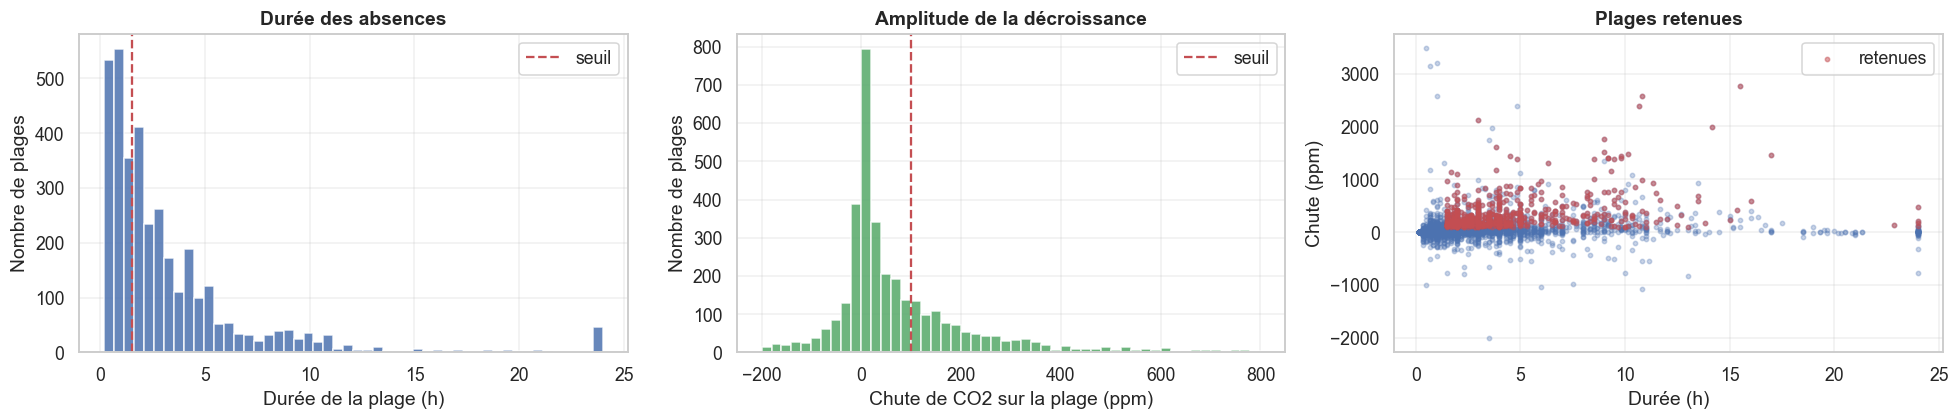

In [3]:
# ── Découpage en plages d'absence continue
df = df.sort_values(['CODELIEU', 'DATE', 'tranche'])
df['plage'] = df.groupby(['CODELIEU', 'DATE'])['dans_logement'].transform(
    lambda s: s.ne(s.shift()).cumsum())

plages = (df[~df['dans_logement']]
          .groupby(['CODELIEU', 'DATE', 'plage'])
          .agg(duree=('tranche', 'size'), heure_debut=('tranche', 'min'),
               c_debut=('VALEUR', 'first'), c_fin=('VALEUR', 'last')))
plages['chute'] = plages['c_debut'] - plages['c_fin']

print(f'{len(plages):,} plages d\'absence · '
      f'{plages.index.get_level_values("CODELIEU").nunique()} logements')

# Trois conditions pour qu'un ajustement ait un sens :
#  · durée suffisante — une décroissance ne se lit pas sur quelques points ;
#  · chute nette — sans quoi on ajusterait du bruit ;
#  · concentration finale au-dessus de l'extérieur, faute de quoi le logarithme
#    n'est pas défini et l'équilibre est déjà atteint.
DUREE_MIN, CHUTE_MIN, MARGE_EXT = 9, 100, 20
retenues = plages[(plages['duree'] >= DUREE_MIN) &
                  (plages['chute'] >= CHUTE_MIN) &
                  (plages['c_fin'] > C_EXT + MARGE_EXT)]

print(f'\nCritères : durée ≥ {DUREE_MIN} tranches ({DUREE_MIN*10/60:.1f} h) · '
      f'chute ≥ {CHUTE_MIN} ppm · concentration finale > {C_EXT + MARGE_EXT:.0f} ppm')
print(f'→ {len(retenues):,} plages exploitables · '
      f'{retenues.index.get_level_values("CODELIEU").nunique()} logements')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(plages['duree'] * 10 / 60, bins=50, color='#4C72B0', alpha=0.85)
axes[0].axvline(DUREE_MIN * 10 / 60, color='#C44E52', lw=1.5, ls='--', label='seuil')
axes[0].set_xlabel('Durée de la plage (h)'); axes[0].set_ylabel('Nombre de plages')
axes[0].set_title('Durée des absences', fontweight='bold'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(plages['chute'], bins=50, range=(-200, 800), color='#55A868', alpha=0.85)
axes[1].axvline(CHUTE_MIN, color='#C44E52', lw=1.5, ls='--', label='seuil')
axes[1].set_xlabel('Chute de CO2 sur la plage (ppm)'); axes[1].set_ylabel('Nombre de plages')
axes[1].set_title('Amplitude de la décroissance', fontweight='bold'); axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].scatter(plages['duree'] * 10 / 60, plages['chute'], s=8, alpha=0.3, color='#4C72B0')
axes[2].scatter(retenues['duree'] * 10 / 60, retenues['chute'], s=8, alpha=0.5, color='#C44E52',
                label='retenues')
axes[2].set_xlabel('Durée (h)'); axes[2].set_ylabel('Chute (ppm)')
axes[2].set_title('Plages retenues', fontweight='bold'); axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## 2. Estimation du taux de renouvellement

En passant l'équation au logarithme, la décroissance devient une droite :

$$\ln(C(t) - C_{ext}) = \ln(C_0 - C_{ext}) - n\,t$$

La pente de cette droite donne directement **−n**. On ajuste par moindres
carrés, en conservant le coefficient de détermination R² : un ajustement de
mauvaise qualité signale une plage qui ne suit pas le modèle — occupant revenu
sans l'avoir déclaré, fenêtre ouverte puis refermée, ou capteur instable.


In [4]:
d_idx = df.set_index(['CODELIEU', 'DATE', 'plage']).sort_index()

resultats = []
for cle in retenues.index:
    seg = d_idx.loc[cle]
    y = seg['VALEUR'].to_numpy() - C_EXT
    if (y <= 0).any():
        continue
    t = np.arange(len(y)) / 6.0                       # en heures
    ly = np.log(y)
    pente, ordonnee = np.polyfit(t, ly, 1)
    if pente >= 0:                                     # pas une décroissance
        continue
    # R² de l'ajustement logarithmique
    pred = pente * t + ordonnee
    ss_res = ((ly - pred) ** 2).sum()
    ss_tot = ((ly - ly.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    resultats.append({'CODELIEU': cle[0], 'DATE': cle[1], 'plage': cle[2],
                      'ach': -pente, 'r2': r2, 'duree': len(y),
                      'c_debut': seg['VALEUR'].iloc[0],
                      'heure_debut': seg['tranche'].iloc[0] / 6})

est = pd.DataFrame(resultats)
print(f'{len(est):,} ajustements réalisés · {est["CODELIEU"].nunique()} logements')
print(f'Qualité de l\'ajustement (R²) : médiane {est["r2"].median():.3f}')

# On écarte les ajustements médiocres : la décroissance n'y est pas exponentielle,
# signe que l'hypothèse d'inoccupation ou de ventilation constante ne tient pas.
R2_MIN = 0.90
est = est[est['r2'] >= R2_MIN]
print(f'\nAprès filtrage R² ≥ {R2_MIN} : {len(est):,} estimations · '
      f'{est["CODELIEU"].nunique()} logements')


580 ajustements réalisés · 234 logements
Qualité de l'ajustement (R²) : médiane 0.975

Après filtrage R² ≥ 0.9 : 453 estimations · 196 logements


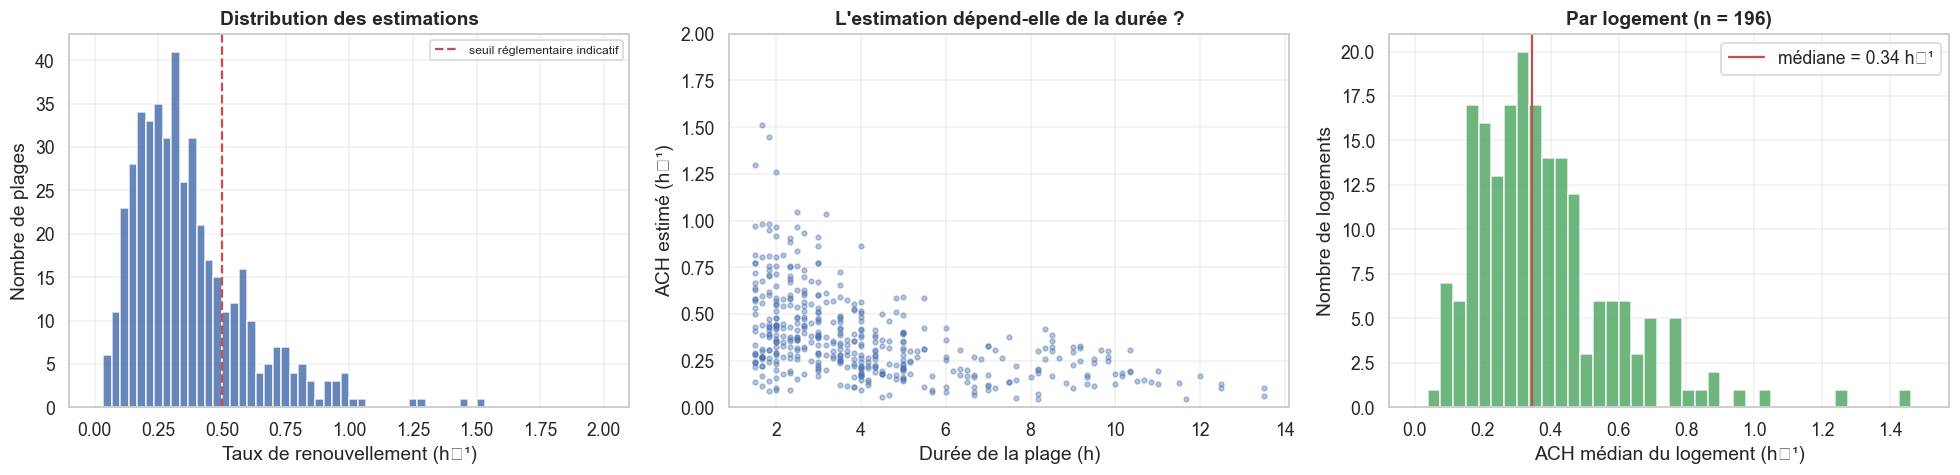

Taux de renouvellement estimé (h⁻¹), par logement :
    5e centile : 0.13
   25e centile : 0.24
   50e centile : 0.34
   75e centile : 0.46
   95e centile : 0.77

Logements sous 0.5 h⁻¹ : 79 %
Plages par logement : médiane 2, max 11


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].hist(est['ach'], bins=60, range=(0, 2), color='#4C72B0', alpha=0.85)
for x, lab, col in [(0.5, 'seuil réglementaire indicatif', '#C44E52')]:
    axes[0].axvline(x, color=col, lw=1.5, ls='--', label=lab)
axes[0].set_xlabel('Taux de renouvellement (h⁻¹)'); axes[0].set_ylabel('Nombre de plages')
axes[0].set_title('Distribution des estimations', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].scatter(est['duree'] * 10 / 60, est['ach'], s=10, alpha=0.4, color='#4C72B0')
axes[1].set_xlabel('Durée de la plage (h)'); axes[1].set_ylabel('ACH estimé (h⁻¹)')
axes[1].set_ylim(0, 2)
axes[1].set_title('L\'estimation dépend-elle de la durée ?', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Médiane par logement : plusieurs plages peuvent exister pour un même logement
par_log = est.groupby('CODELIEU').agg(
    ach=('ach', 'median'), n_plages=('ach', 'size'), r2=('r2', 'median'))
axes[2].hist(par_log['ach'], bins=40, range=(0, 1.5), color='#55A868', alpha=0.85)
axes[2].axvline(par_log['ach'].median(), color='#C44E52', lw=1.5,
                label=f'médiane = {par_log["ach"].median():.2f} h⁻¹')
axes[2].set_xlabel('ACH médian du logement (h⁻¹)'); axes[2].set_ylabel('Nombre de logements')
axes[2].set_title(f'Par logement (n = {len(par_log)})', fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print('Taux de renouvellement estimé (h⁻¹), par logement :')
for q in [0.05, 0.25, 0.50, 0.75, 0.95]:
    print(f'  {int(q*100):>3}e centile : {par_log["ach"].quantile(q):.2f}')
print(f'\nLogements sous 0.5 h⁻¹ : {(par_log["ach"] < 0.5).mean()*100:.0f} %')
print(f'Plages par logement : médiane {par_log["n_plages"].median():.0f}, '
      f'max {par_log["n_plages"].max()}')


**Lecture physique.** Les ordres de grandeur attendus, d'après la littérature sur
la ventilation résidentielle :

| Situation | Taux de renouvellement |
|---|---|
| Logement très étanche, ventilation défaillante | < 0.2 h⁻¹ |
| Ventilation naturelle | 0.2 – 0.5 h⁻¹ |
| VMC en bon fonctionnement | 0.5 – 1 h⁻¹ |
| Fenêtre ouverte | > 2 h⁻¹ |

L'arrêté du 24 mars 1982 impose en France un renouvellement de l'ordre de
0.5 h⁻¹ en logement. Les valeurs obtenues se situent donc à comparer à ce repère.


## 3. Confrontation au type de ventilation déclaré

C'est le test de validité : les estimations issues du signal doivent s'ordonner
conformément aux équipements déclarés par les occupants. Un logement à VMC
devrait afficher un renouvellement supérieur à un logement sans ventilation.


196 logements avec une estimation · 196 avec ventilation renseignée

             size  median   mean
ventilation                     
Aucune         38   0.279  0.351
Naturelle      62   0.334  0.390
Extracteurs    17   0.303  0.374
VMC            79   0.350  0.389

Test de Kruskal-Wallis : p = 0.3194
  → aucune différence nette entre types de ventilation


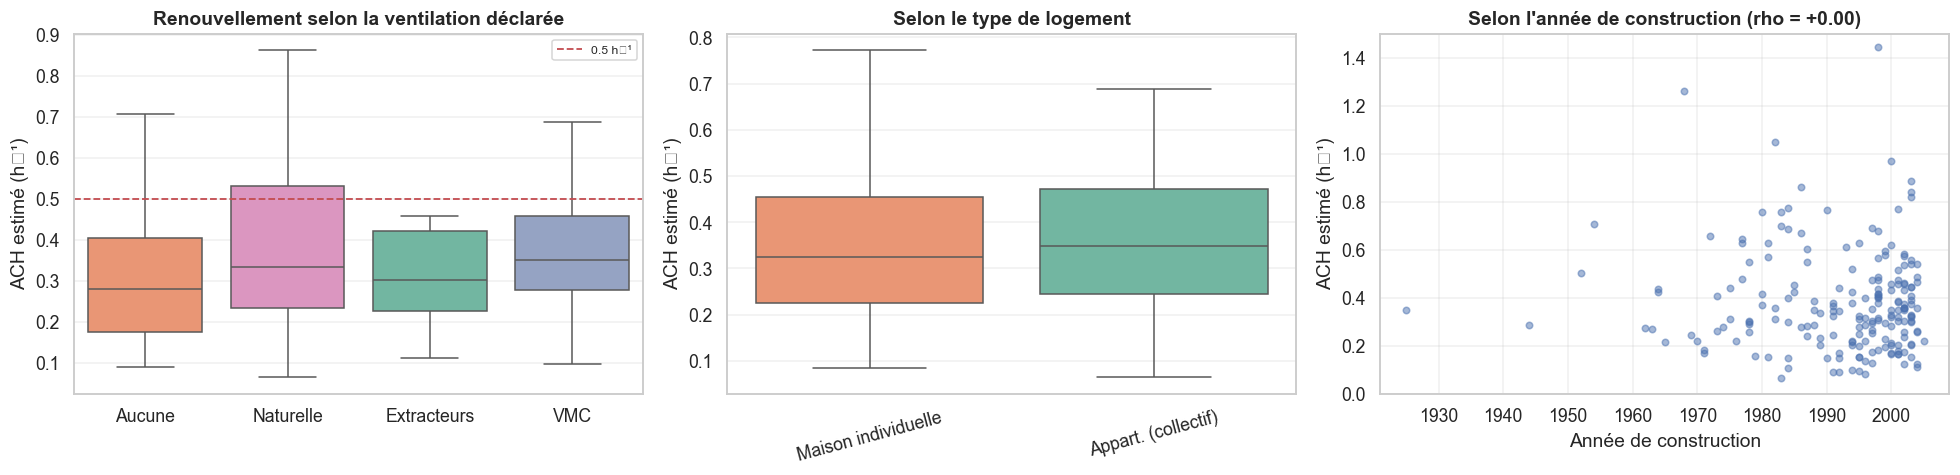

Surface                  rho = +0.077  (p = 0.2856)
Année de construction    rho = +0.004  (p = 0.9504)


In [6]:
KVNT_LABELS = {1: 'VMC', 2: 'Extracteurs', 3: 'Naturelle', 4: 'Aucune'}
KVSY_LABELS = {1: 'Simple flux', 2: 'Double flux'}
FC3_LABELS = {1: 'Maison individuelle', 2: 'Appart. (collectif)', 3: 'Studio (collectif)'}

q = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                sep=';', encoding='latin1',
                usecols=['CODELIEU', 'KVNT', 'KVSY', 'FC3', 'HSRF', 'MA1A']
                ).set_index('CODELIEU')
num = lambda c: pd.to_numeric(q[c], errors='coerce')
carac = pd.DataFrame({
    'ventilation':   num('KVNT').map(KVNT_LABELS),
    'systeme':       num('KVSY').map(KVSY_LABELS),
    'type_logement': num('FC3').map(FC3_LABELS),
    'surface':       num('HSRF'),
    'annee_constr':  num('MA1A'),
})

V = par_log.join(carac)
V = V[V['n_plages'] >= 1]
print(f'{len(V)} logements avec une estimation · '
      f'{V["ventilation"].notna().sum()} avec ventilation renseignée\n')

from scipy.stats import kruskal, spearmanr
ordre = ['Aucune', 'Naturelle', 'Extracteurs', 'VMC']
ordre = [o for o in ordre if (V['ventilation'] == o).sum() >= 10]

tab = V.dropna(subset=['ventilation']).groupby('ventilation')['ach'].agg(['size', 'median', 'mean'])
print(tab.loc[[o for o in ordre]].round(3).to_string())

grp = [V.loc[V['ventilation'] == o, 'ach'].dropna().values for o in ordre]
p = kruskal(*grp).pvalue
print(f'\nTest de Kruskal-Wallis : p = {p:.4f}')
print('  →', 'les types de ventilation se distinguent' if p < 0.05
      else "aucune différence nette entre types de ventilation")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

sns.boxplot(data=V[V['ventilation'].isin(ordre)], x='ventilation', y='ach', order=ordre,
            ax=axes[0], hue='ventilation', palette='Set2', legend=False, showfliers=False)
axes[0].axhline(0.5, color='#C44E52', lw=1.2, ls='--', label='0.5 h⁻¹')
axes[0].set_xlabel(''); axes[0].set_ylabel('ACH estimé (h⁻¹)')
axes[0].set_title('Renouvellement selon la ventilation déclarée', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(True, axis='y', alpha=0.3)

sub_t = V.dropna(subset=['type_logement'])
ordre_t = [o for o in ['Maison individuelle', 'Appart. (collectif)', 'Studio (collectif)']
           if (sub_t['type_logement'] == o).sum() >= 10]
sns.boxplot(data=sub_t[sub_t['type_logement'].isin(ordre_t)], x='type_logement', y='ach',
            order=ordre_t, ax=axes[1], hue='type_logement', palette='Set2',
            legend=False, showfliers=False)
axes[1].set_xlabel(''); axes[1].set_ylabel('ACH estimé (h⁻¹)')
axes[1].set_title('Selon le type de logement', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15); axes[1].grid(True, axis='y', alpha=0.3)

sub_a = V.dropna(subset=['annee_constr'])
sub_a = sub_a[(sub_a['annee_constr'] > 1800) & (sub_a['annee_constr'] <= 2005)]
axes[2].scatter(sub_a['annee_constr'], sub_a['ach'], s=18, alpha=0.5, color='#4C72B0')
rho_a, p_a = spearmanr(sub_a['annee_constr'], sub_a['ach'])
axes[2].set_xlabel('Année de construction'); axes[2].set_ylabel('ACH estimé (h⁻¹)')
axes[2].set_ylim(0, 1.5)
axes[2].set_title(f'Selon l\'année de construction (rho = {rho_a:+.2f})', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

for v, nom in [('surface', 'Surface'), ('annee_constr', 'Année de construction')]:
    s = V.dropna(subset=[v])
    if v == 'annee_constr':
        s = s[(s[v] > 1800) & (s[v] <= 2005)]
    rho, pp = spearmanr(s[v], s['ach'])
    print(f'{nom:<24} rho = {rho:+.3f}  (p = {pp:.4f})')


## 4. Le renouvellement d'air aide-t-il à compter les occupants ?

C'était la motivation de départ. En régime établi, la concentration s'écrit

$$C - C_{ext} = \frac{G}{n\,V}$$

où **G** est le débit de CO2 produit — proportionnel au nombre d'occupants — et
**V** le volume. En réarrangeant :

$$G \propto (C - C_{ext}) \times n \times V$$

Autrement dit, une même concentration correspond à deux fois plus d'occupants si
le renouvellement est deux fois plus élevé. Corriger la concentration par le
taux de renouvellement devrait donc mieux refléter le nombre de personnes
présentes.

**Réserve importante** : le capteur mesure une pièce, dont le volume est inconnu.
On utilise la surface du logement comme approximation, ce qui introduit une
imprécision — mais l'effet du terme *n* peut être testé indépendamment.


In [7]:
# ── Reconstitution du nombre d'occupants dans la pièce du capteur
cap = (pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt', sep='\t',
                   encoding='latin1', usecols=['CODELIEU', 'IDN_PIECE'])
       .groupby('CODELIEU')['IDN_PIECE'].first())
sem['piece_capteur'] = sem['CODELIEU'].map(cap)
sem['dans_piece'] = renseigne & (sem['IDN_PIECE'] == sem['piece_capteur'])
occ = (sem.groupby(['CODELIEU', 'DATE', 'tranche'])
       .agg(n_occ=('dans_piece', 'sum'), n_declares=('IDN_PIECE', 'size'),
            n_renseignes=('IDN_PIECE', 'count')).reset_index())
occ = occ[occ['n_declares'] == occ['n_renseignes']]

A = (co2[['CODELIEU', 'DATE', 'tranche', 'VALEUR']]
     .merge(occ[['CODELIEU', 'DATE', 'tranche', 'n_occ']],
            on=['CODELIEU', 'DATE', 'tranche'], how='inner')
     .merge(par_log[['ach']], left_on='CODELIEU', right_index=True, how='inner')
     .merge(carac[['surface']], left_on='CODELIEU', right_index=True, how='left'))
A = A[A.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('max') < 6000]
A['n_occ'] = A['n_occ'].clip(upper=2)

# Trois indicateurs, du plus simple au plus corrigé
A['exces'] = (A['VALEUR'] - C_EXT).clip(lower=0)          # concentration seule
A['exces_ach'] = A['exces'] * A['ach']                     # corrigée du renouvellement
A['exces_ach_vol'] = A['exces_ach'] * A['surface']         # et du volume approché

print(f'{len(A):,} observations · {A["CODELIEU"].nunique()} logements '
      f'(ceux disposant d\'une estimation d\'ACH)\n')

# Comparaison sur la tâche difficile : 1 occupant contre 2 ou plus
from sklearn.metrics import roc_auc_score
occupe = A[A['n_occ'] > 0].dropna(subset=['exces_ach_vol'])
y = (occupe['n_occ'] == 2).astype(int)

print('Pouvoir discriminant pour distinguer 1 occupant de 2 ou plus :')
for col, nom in [('exces', 'Concentration seule'),
                 ('exces_ach', '× taux de renouvellement'),
                 ('exces_ach_vol', '× renouvellement × surface')]:
    print(f'  {nom:<30} AUC = {roc_auc_score(y, occupe[col]):.3f}')

# Un logement au renouvellement élevé accumule moins : sa concentration
# sous-estime le nombre d'occupants. L'effet est-il visible ?
med = par_log['ach'].median()
A['ventilation_forte'] = A['CODELIEU'].map(par_log['ach']) > med
comp = (A[A['n_occ'] > 0].groupby(['ventilation_forte', 'n_occ'])['exces']
        .median().unstack())
comp.index = ['Renouvellement faible', 'Renouvellement élevé']
print('\nExcès de CO2 médian (ppm) selon le nombre d\'occupants :')
print(comp.round(0).to_string())


155,683 observations · 196 logements (ceux disposant d'une estimation d'ACH)

Pouvoir discriminant pour distinguer 1 occupant de 2 ou plus :
  Concentration seule            AUC = 0.603
  × taux de renouvellement       AUC = 0.639
  × renouvellement × surface     AUC = 0.683

Excès de CO2 médian (ppm) selon le nombre d'occupants :
n_occ                      1      2
Renouvellement faible  654.0  981.0
Renouvellement élevé   488.0  600.0


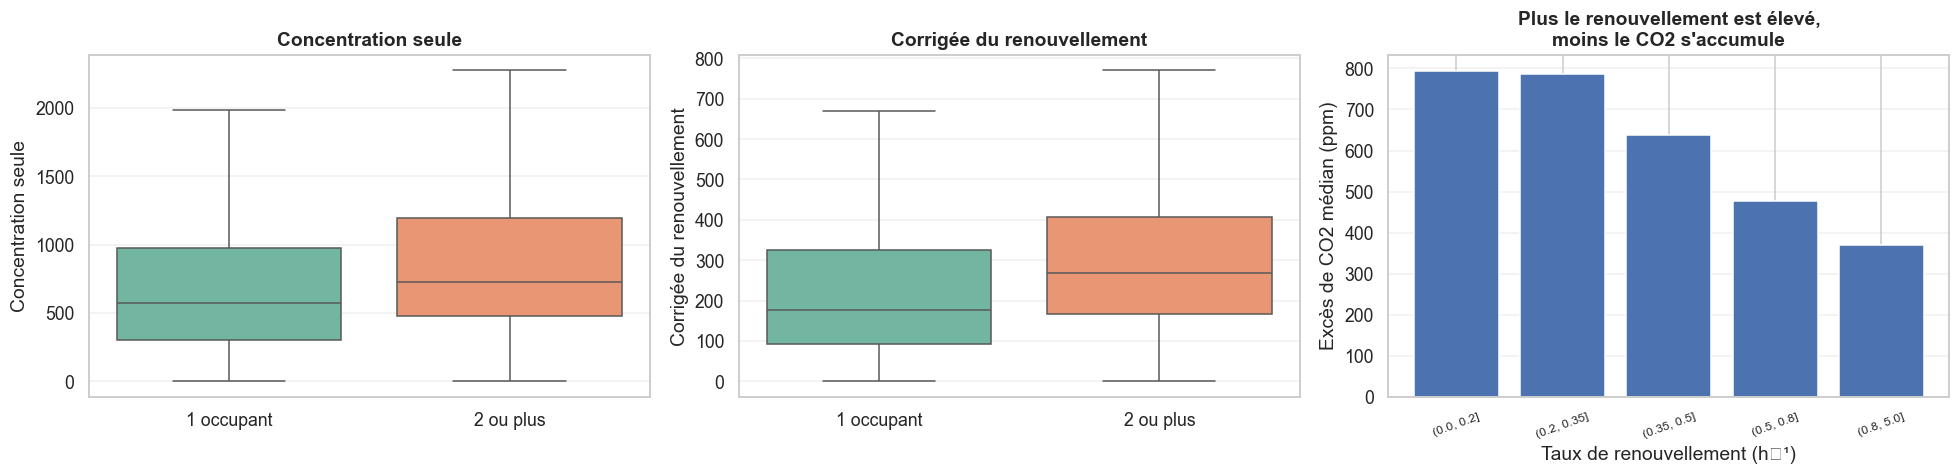

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, (col, titre) in zip(axes[:2], [('exces', 'Concentration seule'),
                                       ('exces_ach', 'Corrigée du renouvellement')]):
    sub = A[A['n_occ'] > 0]
    sns.boxplot(data=sub, x='n_occ', y=col, ax=ax, hue='n_occ',
                palette='Set2', legend=False, showfliers=False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['1 occupant', '2 ou plus'])
    ax.set_xlabel(''); ax.set_ylabel(titre)
    ax.set_title(titre, fontweight='bold'); ax.grid(True, axis='y', alpha=0.3)

# Le CO2 accumulé décroît-il bien quand le renouvellement augmente ?
occupe_nuit = A[(A['n_occ'] > 0)]
prof = occupe_nuit.groupby(pd.cut(occupe_nuit['ach'], [0, .2, .35, .5, .8, 5]),
                           observed=True)['exces'].median()
axes[2].bar(range(len(prof)), prof.values, color='#4C72B0')
axes[2].set_xticks(range(len(prof)))
axes[2].set_xticklabels([str(i) for i in prof.index], rotation=20, fontsize=8)
axes[2].set_xlabel('Taux de renouvellement (h⁻¹)')
axes[2].set_ylabel('Excès de CO2 médian (ppm)')
axes[2].set_title('Plus le renouvellement est élevé,\nmoins le CO2 s\'accumule',
                  fontweight='bold')
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout(); plt.show()


## 5. Sensibilité au choix de la concentration extérieure

L'estimation repose sur une valeur supposée du CO2 extérieur, non mesurée dans
cette campagne. Il faut vérifier que les conclusions ne dépendent pas de ce choix.


,C_ext (ppm),plages,ACH médian,ACH q25,ACH q75
0,350,594,0.239,0.157,0.351
1,380,588,0.270,0.176,0.408
2,400,580,0.303,0.194,0.452
3,420,569,0.334,0.217,0.533
4,450,484,0.361,0.235,0.568


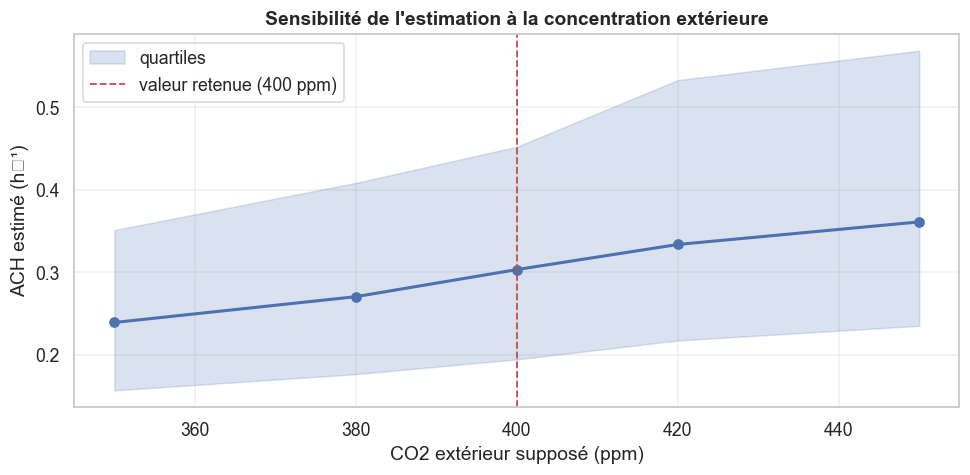

Écart relatif de l'ACH médian sur la plage testée : 40 %


In [9]:
lignes = []
for c_ext in [350, 380, 400, 420, 450]:
    vals = []
    for cle in retenues.index:
        seg = d_idx.loc[cle]
        y = seg['VALEUR'].to_numpy() - c_ext
        if (y <= 0).any():
            continue
        t = np.arange(len(y)) / 6.0
        pente = np.polyfit(t, np.log(y), 1)[0]
        if pente < 0:
            vals.append(-pente)
    lignes.append({'C_ext (ppm)': c_ext, 'plages': len(vals),
                   'ACH médian': np.median(vals), 'ACH q25': np.percentile(vals, 25),
                   'ACH q75': np.percentile(vals, 75)})

sens = pd.DataFrame(lignes)
display(sens.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sens['C_ext (ppm)'], sens['ACH médian'], marker='o', lw=2, color='#4C72B0')
ax.fill_between(sens['C_ext (ppm)'], sens['ACH q25'], sens['ACH q75'],
                alpha=0.2, color='#4C72B0', label='quartiles')
ax.axvline(C_EXT, color='#C44E52', lw=1.2, ls='--', label=f'valeur retenue ({C_EXT:.0f} ppm)')
ax.set_xlabel('CO2 extérieur supposé (ppm)'); ax.set_ylabel('ACH estimé (h⁻¹)')
ax.set_title('Sensibilité de l\'estimation à la concentration extérieure',
             fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

ecart = (sens['ACH médian'].max() - sens['ACH médian'].min()) / sens['ACH médian'].median()
print(f"Écart relatif de l'ACH médian sur la plage testée : {ecart*100:.0f} %")


## 6. Synthèse

### La méthode fonctionne

453 estimations sur 196 logements, avec un **R² médian de 0.975** : les
décroissances observées suivent très fidèlement le modèle exponentiel attendu.
Ce n'était pas acquis — un ajustement médiocre aurait signalé des occupants non
déclarés, des fenêtres ouvertes, ou un mélange d'air trop lent pour que le modèle
s'applique.

### Le parc est majoritairement sous-ventilé

| | Taux de renouvellement estimé |
|---|---|
| 5ᵉ centile | 0.13 h⁻¹ |
| 1ᵉʳ quartile | 0.24 h⁻¹ |
| **Médiane** | **0.34 h⁻¹** |
| 3ᵉ quartile | 0.46 h⁻¹ |
| 95ᵉ centile | 0.77 h⁻¹ |

**79 % des logements se situent sous 0.5 h⁻¹**, ordre de grandeur attendu en
logement d'après la réglementation. Ces valeurs restent cohérentes avec un parc
résidentiel des années 2000, mais elles confirment un défaut de renouvellement
largement répandu.

### La ventilation déclarée ne prédit pas le renouvellement mesuré

| Ventilation déclarée | Logements | ACH médian |
|---|---|---|
| Aucune | 38 | 0.279 |
| Extracteurs | 17 | 0.303 |
| Naturelle | 62 | 0.334 |
| VMC | 79 | 0.350 |

L'ordre va dans le sens attendu, mais les écarts sont faibles et **non
significatifs** (p = 0.32). Ni la surface ni l'année de construction ne montrent
de lien (rho = +0.08 et +0.004).

Deux lectures sont possibles :

- *la méthode ne mesure pas ce qu'elle prétend* — peu probable au vu du R² de
  0.975 et du résultat de la section suivante, qui la valide indépendamment ;
- *les équipements déclarés ne fonctionnent pas comme prévu* — hypothèse plus
  vraisemblable. Une VMC obstruée, arrêtée ou mal entretenue ne renouvelle pas
  mieux qu'une ventilation naturelle. Le fait qu'un logement soit **équipé** ne
  garantit pas qu'il soit **ventilé**.

Cette seconde lecture constitue en soi un résultat pour un travail portant sur la
qualité de l'air intérieur.

### Le renouvellement d'air améliore le dénombrement

C'était la motivation initiale, et l'hypothèse se vérifie :

| Indicateur | AUC (1 occupant contre 2 ou plus) |
|---|---|
| Concentration seule | 0.603 |
| × taux de renouvellement | 0.639 |
| **× renouvellement × surface** | **0.683** |

Le mécanisme se lit directement dans les concentrations médianes :

| | 1 occupant | 2 occupants ou plus |
|---|---|---|
| Renouvellement faible | 654 ppm | 981 ppm |
| Renouvellement élevé | 488 ppm | 600 ppm |

**Deux personnes dans un logement bien ventilé produisent moins de CO2 mesuré
qu'une seule dans un logement confiné** (600 contre 654 ppm). C'est exactement ce
que prédisait l'équation de bilan, et cela explique pourquoi le dénombrement
échouait tant qu'on regardait la concentration seule.

Ce gain constitue par ailleurs une **validation indépendante** de la méthode : si
les valeurs estimées n'étaient que du bruit, les intégrer ne pourrait pas
améliorer une prédiction.

### Limites

**Sensibilité à la concentration extérieure.** Elle n'a pas été mesurée pendant
la campagne. Faire varier l'hypothèse de 350 à 450 ppm déplace l'ACH médian de
0.24 à 0.36 h⁻¹, soit **40 % d'écart relatif**. Les comparaisons entre logements
restent valides — tous subissent le même décalage — mais les valeurs absolues
doivent être maniées avec prudence.

**Le volume de la pièce est inconnu.** Le capteur mesure une pièce, la surface
disponible est celle du logement entier. L'approximation reste grossière, ce qui
n'empêche pas le terme correctif d'apporter un gain mesurable.

**Une couverture partielle.** 196 logements sur 451 disposent d'une estimation :
les autres n'ont pas connu de période d'inoccupation à la fois assez longue et
assez marquée. Les logements très occupés sont donc sous-représentés, ce qui peut
biaiser la distribution obtenue.

**Hypothèses du modèle.** Renouvellement constant sur la plage et mélange
homogène de l'air. Ni l'un ni l'autre n'est rigoureusement vérifié en conditions
réelles.
